In [28]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/04_decision-tree-example.ipynb 04_decision-tree-example.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/04_decision-tree-example.ipynb 04_decision-tree-example.ipynb

[NbConvertApp] Converting notebook 04_decision-tree-example.ipynb to notebook
[NbConvertApp] Writing 677828 bytes to ../exercises/04_decision-tree-example.ipynb
[NbConvertApp] Converting notebook 04_decision-tree-example.ipynb to notebook
[NbConvertApp] Writing 707882 bytes to ../solutions/04_decision-tree-example.ipynb


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns

import sklearn

# Problem presentation
We want to determine whether there is snow or not at the Folgefonna skisenter based on other variables

# STEP 01 PREPROCESSING DATA
The data is loaded with pandas, a library allowing to extract data from csv table files.


## Load data from file
The numpy array are provided in X_data and y_data variables

In [3]:
df = pd.read_csv('../data/folgefonna-skisenter_vaeret.csv', index_col=0)
df=df.dropna()

In [4]:
df

,Tmax,Tmean,Tmin,Pr,Snowdepth,wind
date,,,,,,
2015-10-01,5.2,3.5,2.2,1.0,0.0,6.1
2015-10-02,4.2,2.9,2.4,3.5,0.0,6.3
2015-10-03,4.5,2.4,-0.6,17.6,0.0,4.1
2015-10-04,3.4,2.5,1.7,0.6,0.0,1.6
2015-10-05,7.4,5.1,2.4,15.9,0.0,8.3
...,...,...,...,...,...,...
2025-09-04,10.5,8.0,7.0,22.0,0.0,6.1
2025-09-05,9.0,7.4,6.1,6.3,0.0,5.7
2025-09-06,8.9,6.7,4.0,6.5,0.0,2.1


In [5]:
X_data= df[['Tmin','wind',]].values
y_data = df['Snowdepth'].values

## Reshape data

In [6]:
X = ...
y = ...

In [7]:
print(X_data.shape)
print(y_data.shape)

X = X_data
y = y_data.reshape(-1,1)

print(y.shape)

(2369, 2)
(2369,)
(2369, 1)


## Split data into train and test data.
We ignore the validation dataset in that case


In [8]:
X_train, X_test, y_train, y_test = ...

TypeError: cannot unpack non-iterable ellipsis object

In [9]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, train_size=0.7, shuffle=True)

## Transform the data
This is not needed for decision tree, but we can still practice

In [10]:
scaler_X = ...
...
X_train_rescaled = ...
X_test_rescaled = ...

tranform_y = ...
...
y_train_rescaled = ...
y_test_rescaled = ...

In [11]:
scaler_X = sklearn.preprocessing.StandardScaler()
scaler_X.fit(X_train)
X_train_rescaled = scaler_X.transform(X_train)
X_test_rescaled = scaler_X.transform(X_test)

tranform_y = sklearn.preprocessing.Binarizer(threshold=0.1)
tranform_y.fit(y_train)
y_train_rescaled = tranform_y.transform(y_train)
y_test_rescaled = tranform_y.transform(y_test)

### Plot example data

Text(38.34419444444444, 0.5, 'Wind (scaled)')

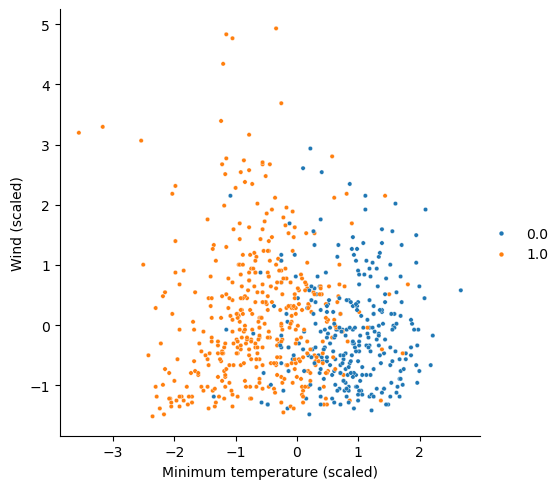

In [12]:
sns.relplot(x=X_test_rescaled[:,0], 
            y=X_test_rescaled[:,1],
            hue=y_test_rescaled[:,0],
            s=10
           )
plt.xlabel('Minimum temperature (scaled)')
plt.ylabel('Wind (scaled)')

# STEP 2: Define ML model and fit it to the data


In [13]:
from sklearn.tree import DecisionTreeClassifier

## Choose hyperparameters

In [14]:
max_depth = ...

In [15]:
max_depth = 3
min_samples_leaf=5

## Create model

In [16]:
model = ...

In [17]:
model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)

In [18]:
model

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Fit the model to the data

In [19]:
...

Ellipsis

In [20]:
model.fit(X_train_rescaled, y_train_rescaled)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Plot the tree in the 2d space

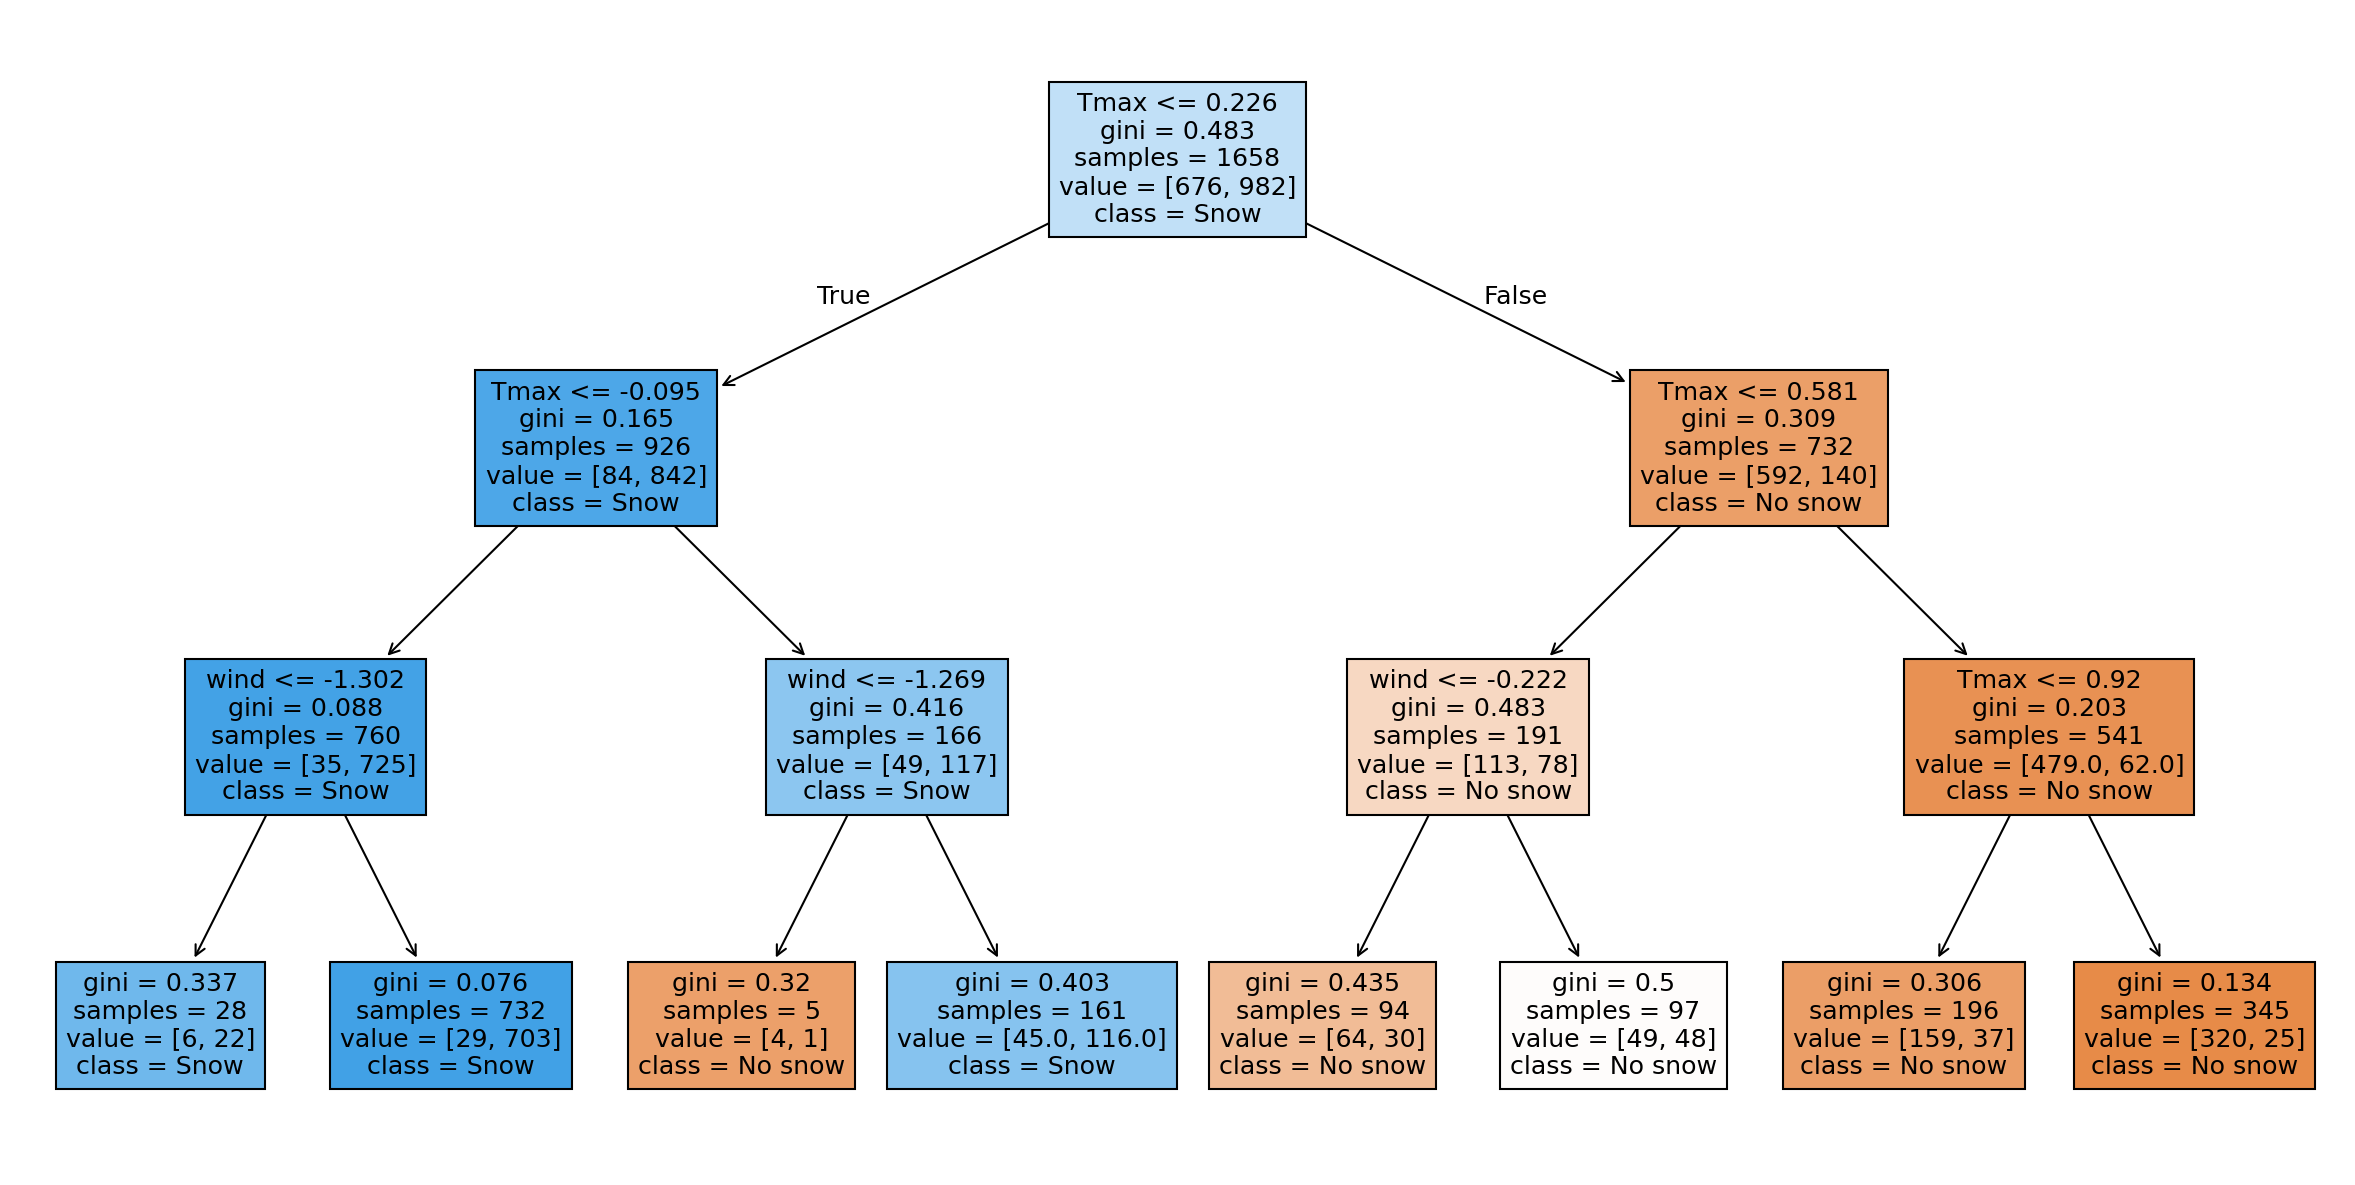

In [21]:
# STEP 01 PREPROCESSING DATA
fig, ax = plt.subplots(dpi=150, figsize=(20,10))
sklearn.tree.plot_tree(model, feature_names=['Tmax', 'wind', 'Pr'],ax=ax, class_names=['No snow','Snow'],filled=True);

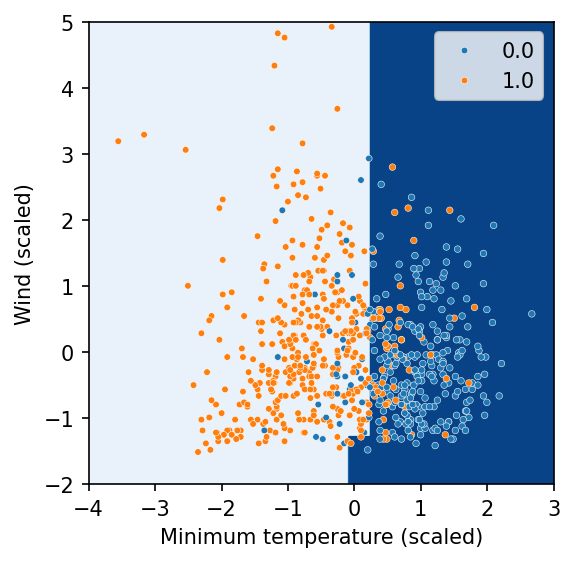

In [27]:
x_min, x_max = -4,3
y_min, y_max = -2, 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, ax = plt.subplots(dpi=150, figsize=(4,4))

sns.scatterplot(x=X_test_rescaled[:,0], 
            y=X_test_rescaled[:,1],
            hue=y_test_rescaled[:,0],
            s=10,
            ax=ax
           )
plt.xlabel('Minimum temperature (scaled)')
plt.ylabel('Wind (scaled)')

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
Z.shape
plot = plt.contourf(xx,yy,Z, zorder=0, cmap='Blues_r', )
# plt.colorbar(plot, label='Probaility of snow')

# STEP 3: Evaluate the model skill


## Predict the results for the test data

In [71]:
predictions_test = ...

In [72]:
predictions_test = model.predict(X_test_rescaled)

## Evaluate the results with `accuracy` and confusion matrix

In [73]:
confusion_matrix = ...
accuracy = ...

In [74]:
confusion_matrix = sklearn.metrics.confusion_matrix(y_test_rescaled, predictions_test)
accuracy = sklearn.metrics.accuracy_score(y_test_rescaled, predictions_test)

print(f"Confusion matrix:\n{confusion_matrix}")
print()
print(f"Accuracy: {accuracy:.02f}")

Confusion matrix:
[[248  41]
 [ 70 352]]

Accuracy: 0.84


### Plot the confusion matrix

[Text(0.5, 0, 'No Snow'), Text(1.5, 0, 'Snow')]

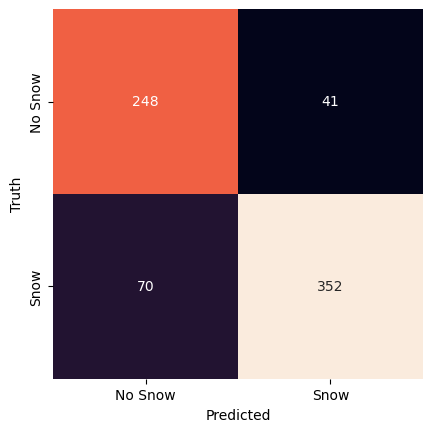

In [75]:
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix, square=True, cbar=False, annot=True, fmt='.0f',ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Truth')
ax.set_yticklabels(['No Snow','Snow'])
ax.set_xticklabels(['No Snow','Snow'])